In [1]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/creditcardfraud


Dataset shape: (284807, 31)

Data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class   

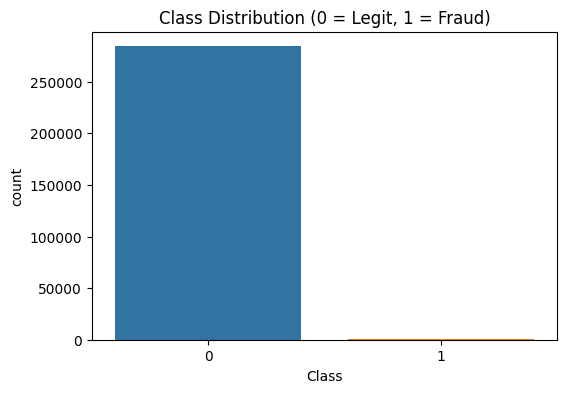

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


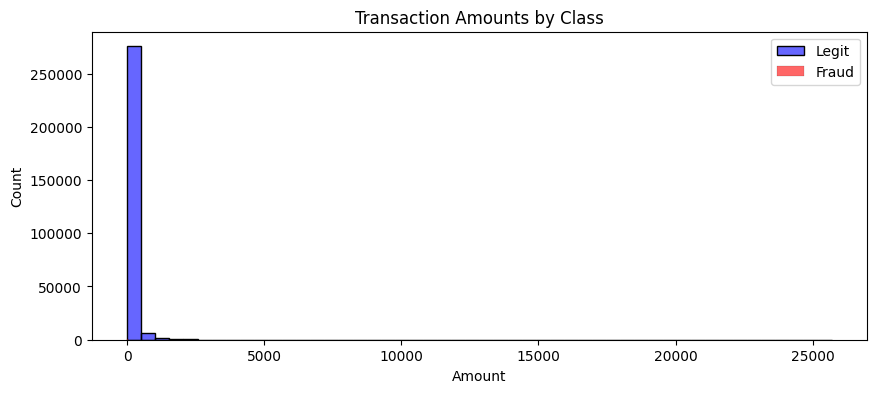

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset_path = "/kaggle/input/creditcardfraud/creditcard.csv"
df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:\n", df.head())

print("\nClass distribution:\n", df['Class'].value_counts())
print("\nPercentage distribution:\n", df['Class'].value_counts(normalize=True) * 100)

print("\nStatistical summary:\n", df.describe())
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', label='Legit', alpha=0.6)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', alpha=0.6)
plt.title("Transaction Amounts by Class")
plt.legend()
plt.show()

=== Random Forest Report ===
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8081    0.8163    0.8122        98

    accuracy                         0.9994     56962
   macro avg     0.9039    0.9080    0.9059     56962
weighted avg     0.9994    0.9994    0.9994     56962



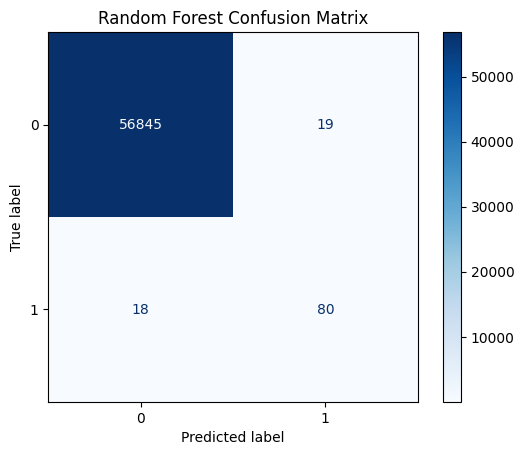

=== XGBoost Report ===
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     56864
           1     0.8710    0.8265    0.8482        98

    accuracy                         0.9995     56962
   macro avg     0.9353    0.9132    0.9240     56962
weighted avg     0.9995    0.9995    0.9995     56962



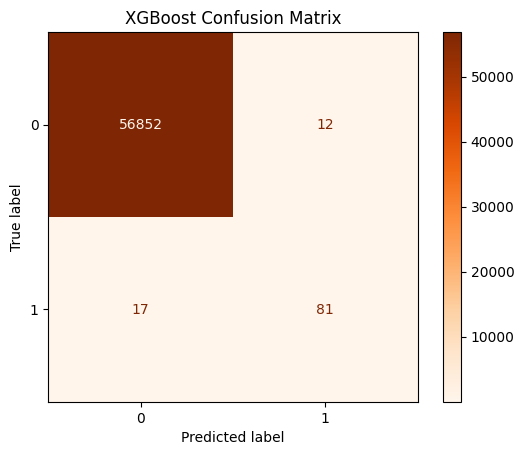

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/creditcardfraud/creditcard.csv"
df = pd.read_csv(dataset_path)

X = df.drop('Class', axis=1)
y = df['Class']


scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X['Hour_of_day'] = (X['Time'] // 3600) % 24
X['Log_Amount'] = np.log1p(X['Amount'])
X['Is_Night'] = ((X['Hour_of_day'] >= 0) & (X['Hour_of_day'] <= 6)).astype(int)
X['Amount_per_Hour'] = X['Amount'] / (X['Hour_of_day'] + 1)
X['High_Amount_Flag'] = (X['Amount'] > X['Amount'].quantile(0.95)).astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf, digits=4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=ratio,  # Balancing factor
    learning_rate=0.05,
    max_depth=6,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Report ===")
print(classification_report(y_test, y_pred_xgb, digits=4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb).plot(cmap='Oranges')
plt.title("XGBoost Confusion Matrix")
plt.show()
